In [1]:

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, Bidirectional, LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

import bz2
import csv
import re

In [6]:
import pandas as pd

train_path = r"C:\Users\Lenovo\OneDrive\Documents\Data set\Sentiment_Anlaysis\train.ft.txt.bz2"
test_path = r"C:\Users\Lenovo\OneDrive\Documents\Data set\Sentiment_Anlaysis\test.ft.txt.bz2"

training_data = pd.read_csv(train_path, compression='bz2', header=None, sep='\t')
test_data = pd.read_csv(test_path, compression='bz2', header=None, sep='\t')


In [7]:
training_data = training_data.sample(12000, random_state=42)
test_data = test_data.sample(3000, random_state=42)

In [8]:
training_data[0]

2079998    __label__1 Expensive Junk: This product consis...
1443106    __label__1 Toast too dark: Even on the lowest ...
3463669    __label__2 Excellent imagery...dumbed down sto...
2914699    __label__1 Are we pretending everyone is marri...
1603231    __label__1 Not worth your time: Might as well ...
                                 ...                        
1256389    __label__1 Wow.: For a long awaited album that...
1774982    __label__1 Disappointing: Upon first removing ...
563145     __label__1 Readers digest has changed!: Reader...
3313215    __label__1 see and learn: I was very disappoin...
804344     __label__1 A 15 Year Olds Objections to Fight ...
Name: 0, Length: 12000, dtype: object

In [10]:
# Split the data into labels and texts
training_labels = [int(re.findall(r'__label__(\d)', line)[0]) for line in training_data[0].values]
training_texts = [re.sub(r'__label__\d ', '', line) for line in training_data[0].values]

test_labels = [int(re.findall(r'__label__(\d)', line)[0]) for line in test_data[0].values]
test_texts = [re.sub(r'__label__\d ', '', line) for line in test_data[0].values]

# Convert labels to binary (0 and 1)
training_labels = [0 if label == 1 else 1 for label in training_labels]
test_labels = [0 if label == 1 else 1 for label in test_labels]

In [12]:
print(test_labels[:4])

[1, 0, 1, 1]


# Text Cleaning

In [18]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer



def clean_text(text):
    ps=PorterStemmer()
    stop_words=set(stopwords.words('english'))

    # Convert to lowercase
    text = text.lower()

     # Remove non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize and remove stopwords, apply stemming
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    # Join words back into a string
    return " ".join(words)

# Apply function to training and test texts
training_texts = [clean_text(text) for text in training_texts]
test_texts = [clean_text(text) for text in test_texts]
    

In [19]:
training_texts[0]

'expens junk product consist piec thin flexibl insul materi adhes back velcro white electr tapeproblem instruct three pictur littl inform velcro crumpl receiv stronger adhes tri disengag velcro piec came paint ceil white electr tape horribl cheap narrow fell less hour price ripoffi build easier use cheaper attract higher rvalu surpris amazon even list junk'

# Tokenization

In [21]:
# Tokenization and padding
max_words=1000
max_sequence_length = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(training_texts)

X_train = tokenizer.texts_to_sequences(training_texts)
X_test = tokenizer.texts_to_sequences(test_texts)

X_train = pad_sequences(X_train, maxlen=max_sequence_length)
X_test = pad_sequences(X_test, maxlen=max_sequence_length)

In [22]:
X_train[:5]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 635, 502,  18, 168, 883, 423,  45, 484, 479, 275, 152,
         41, 159, 150,  33, 168, 170, 484, 592, 311, 280, 756, 205, 254,
         88, 841, 796,   7, 414, 131,  19, 364, 502],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [23]:
X_train = np.array(X_train)
print(X_train.shape)
X_test = np.array(X_test)
print(X_test.shape)
y_train = np.array(training_labels)
print(y_train.shape)
y_test = np.array(test_labels)
print(y_test.shape)

(12000, 100)
(3000, 100)
(12000,)
(3000,)


# Traing RNN  

In [25]:
# Define improved RNN model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Increased embedding size
    SimpleRNN(128, return_sequences=True, dropout=0.3),  # RNN layer with dropout
    LayerNormalization(),  # Added normalization for stability
    SimpleRNN(128, dropout=0.3),  # Second RNN layer
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),  # Extra dense layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile with lower learning rate
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])


# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history=model.fit(X_train, y_train,epochs=50, batch_size=512,validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)



C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 23s 581ms/step - accuracy: 0.5107 - loss: 0.8452 - val_accuracy: 0.5253 - val_loss: 0.7312
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 487ms/step - accuracy: 0.5123 - loss: 0.7996 - val_accuracy: 0.5357 - val_loss: 0.7095
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 493ms/step - accuracy: 0.5211 - loss: 0.7619 - val_accuracy: 0.5233 - val_loss: 0.6959
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 506ms/step - accuracy: 0.5098 - loss: 0.7529 - val_accuracy: 0.5160 - val_loss: 0.6962
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 506ms/step - accuracy: 0.5159 - loss: 0.7352 - val_accuracy: 0.5093 - val_loss: 0.6996
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 498ms/step - accuracy: 0.5134 - loss: 0.7318 - val_accuracy: 0.5087 - val_loss: 0.7004
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 520ms/step - accuracy: 0.5203 - loss: 0.7210 - val_accuracy: 0.5133 - val_loss: 0.6970
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 494ms/step - accuracy: 0.5175 - loss: 0.7177 - val_accu

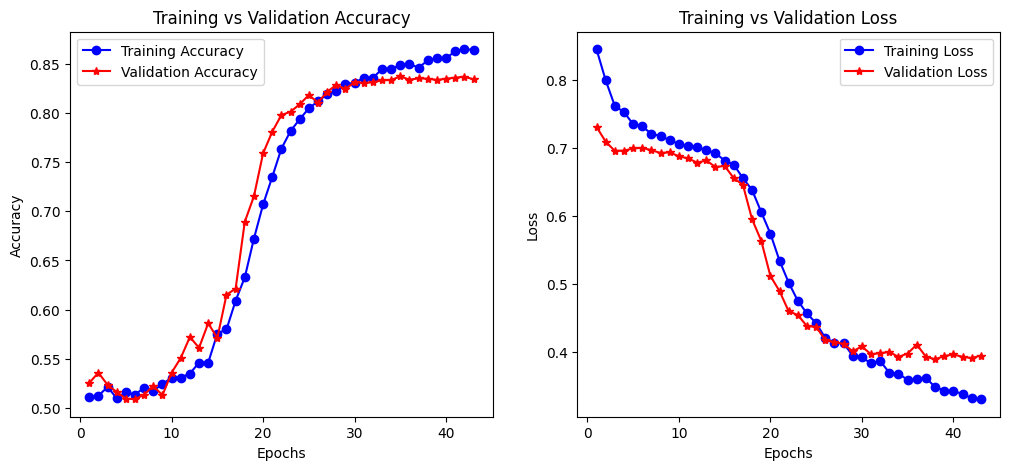

In [27]:


# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()


In [28]:
# Evaluate with a confusion matrix and classification report
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step
Confusion Matrix:
[[1227  272]
 [ 223 1278]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1499
           1       0.82      0.85      0.84      1501

    accuracy                           0.83      3000
   macro avg       0.84      0.83      0.83      3000
weighted avg       0.84      0.83      0.83      3000



# Trainig LSTM

In [29]:
# Define improved model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Increased embedding size
    Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.2)),  # Added recurrent dropout
    LayerNormalization(),  # Added normalization for stability
    Dropout(0.3),
    Bidirectional(LSTM(128, recurrent_dropout=0.2)),  
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),  # Extra dense layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile with lower learning rate
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 138s 4s/step - accuracy: 0.5281 - loss: 0.7682 - val_accuracy: 0.5800 - val_loss: 0.6742
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 99s 4s/step - accuracy: 0.5717 - loss: 0.6847 - val_accuracy: 0.6630 - val_loss: 0.6399
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.6162 - loss: 0.6509 - val_accuracy: 0.6930 - val_loss: 0.5917
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.6810 - loss: 0.5941 - val_accuracy: 0.7303 - val_loss: 0.5307
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 99s 4s/step - accuracy: 0.7277 - loss: 0.5420 - val_accuracy: 0.7627 - val_loss: 0.4933
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.7663 - loss: 0.4891 - val_accuracy: 0.7823 - val_loss: 0.4607
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.7911 - loss: 0.4502 - val_accuracy: 0.8020 - val_loss: 0.4392
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.8082 - loss: 0.4260 - val_accuracy: 0.8077 - val_loss

# MOdel Evaluation

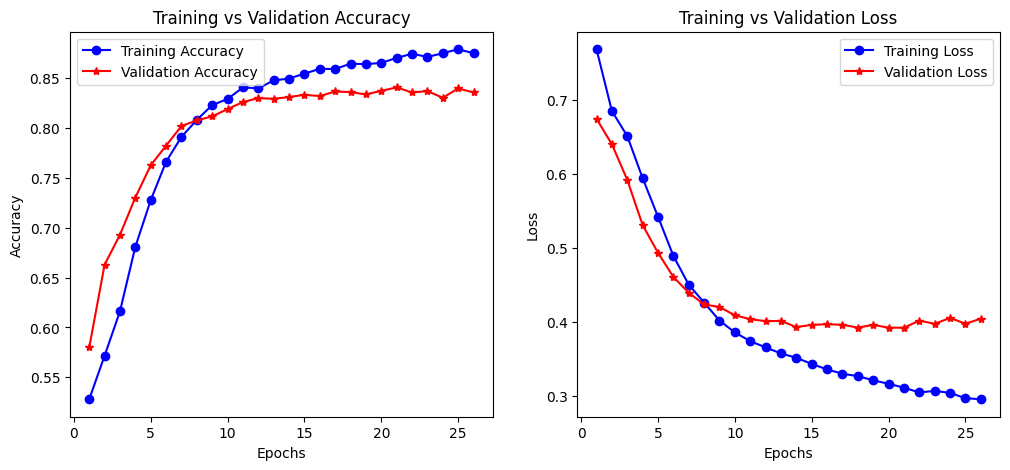

In [30]:
import matplotlib.pyplot as plt

# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [31]:
# Evaluate with a confusion matrix and classification report
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step
Confusion Matrix:
[[1245  254]
 [ 224 1277]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1499
           1       0.83      0.85      0.84      1501

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



# Detection System

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(text, model, tokenizer, max_sequence_length=100):

    text=clean_text(text)
     # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([text])

     # Pad sequence
    padded_sequence = pad_sequences(sequence, maxlen=max_sequence_length)

    # Predict sentiment
    prediction = model.predict(padded_sequence)[0][0]  # Extract scalar value

    
      
    # Determine sentiment
    sentiment = "Positive 😊" if prediction > 0.5 else "Negative 😡

      return sentiment, float(prediction)


# Example usage:
test_sentences = [
    "I love this product! It's amazing.",
    "This is the worst service I have ever experienced.",
    "The movie was okay, not great but not terrible either."
]

for sentence in test_sentences:
    sentiment, confidence = predict_sentiment(sentence, model, tokenizer)
       print(f"Text: {sentence}\nPredicted Sentiment: {sentiment} (Confidence: {confidence:.4f})\n")





1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Text: I love this product! It's amazing.
Predicted Sentiment: Positive 😊 (Confidence: 0.9362)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Text: This is the worst service I have ever experienced.
Predicted Sentiment: Negative 😡 (Confidence: 0.0886)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Text: The movie was okay, not great but not terrible either.
Predicted Sentiment: Negative 😡 (Confidence: 0.2240)



In [34]:
model.save("lstm_model.h5")  # Saves architecture, weights & optimizer


import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)